In [2]:

import os

# Check if Project folder exists
if os.path.exists('/content/Project'):
    os.chdir('/content/Project')
    print("✅ Now in Project folder")
    print("\n📋 Files found:")
    !ls -la *.npy *.pkl *.csv
else:
    print("❌ Project folder not found")
    print("Searching for .npy files...")
    !find /content -name "*.npy" 2>/dev/null

✅ Now in Project folder

📋 Files found:
-rw-r--r-- 1 root root     2112 Feb 14 13:51 feature_importance.csv
-rw-r--r-- 1 root root     1201 Feb 14 13:51 feature_names.pkl
-rw-r--r-- 1 root root 29072471 Feb 14 13:51 feature_selector.pkl
-rw-r--r-- 1 root root      505 Feb 14 13:51 label_encoder.pkl
-rw-r--r-- 1 root root     3207 Feb 14 13:51 scaler.pkl
-rw-r--r-- 1 root root      609 Feb 14 13:51 selected_features.pkl
-rw-r--r-- 1 root root   986287 Feb 14 13:51 student_dropout_encoded.csv
-rw-r--r-- 1 root root   933712 Feb 14 13:51 student_dropout_preprocessed_full.csv
-rw-r--r-- 1 root root   844614 Feb 14 13:51 student_dropout_test.csv
-rw-r--r-- 1 root root   418743 Feb 14 13:51 student_dropout_test_selected.csv
-rw-r--r-- 1 root root  5059652 Feb 14 13:51 student_dropout_train.csv
-rw-r--r-- 1 root root  2509010 Feb 14 13:51 student_dropout_train_selected.csv
-rw-r--r-- 1 root root   339968 Feb 14 13:51 X_test_scaled.npy
-rw-r--r-- 1 root root   170048 Feb 14 13:51 X_test_select

📊 LOADING YOUR DATA
✅ Training data: (5301, 24)
✅ Test data: (885, 24)
✅ Features: 24
✅ Classes: ['Dropout' 'Enrolled' 'Graduate']

🌲 TRAINING RANDOM FOREST MODEL
✅ Model accuracy: 0.7638

🔮 CALCULATING SHAP VALUES
✅ SHAP values calculated!

📊 Creating SHAP plots...


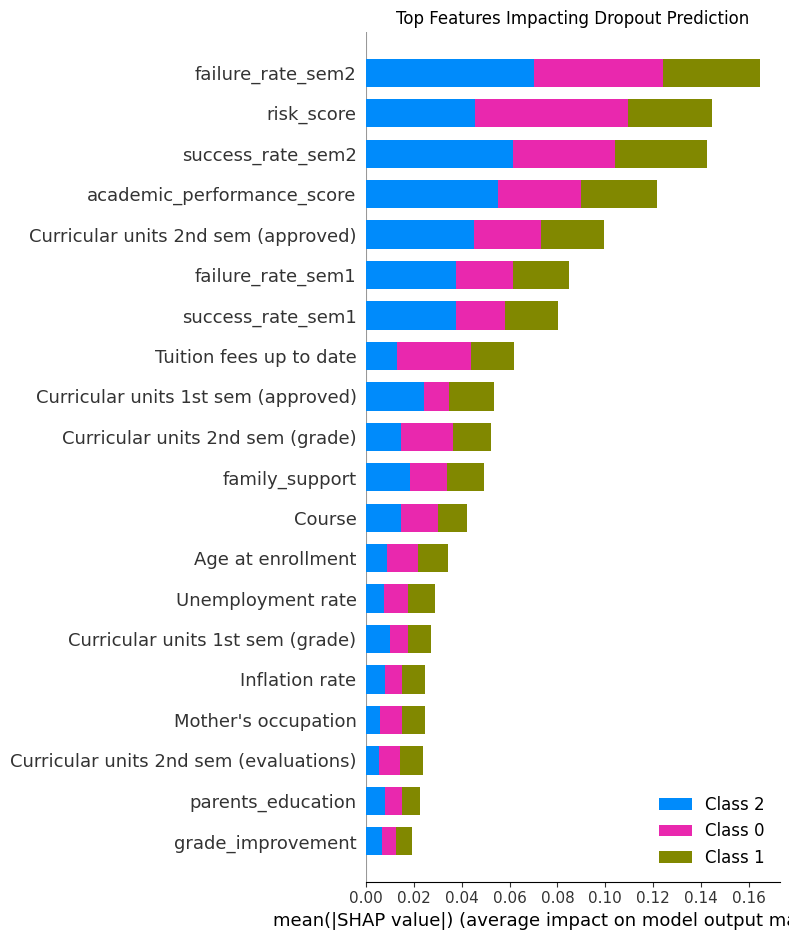

✅ Saved: shap_feature_importance.png

📥 DOWNLOADING RESULTS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [ ]:

# SHAP ANALYSIS (Files are ready!)


# Install SHAP (if not already installed)
!pip install shap matplotlib seaborn --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("📊 LOADING YOUR DATA")
print("="*60)

# Load the data files (they are in current directory)
X_train = np.load('X_train_selected.npy')
X_test = np.load('X_test_selected.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
feature_names = joblib.load('selected_features.pkl')
label_encoder = joblib.load('label_encoder.pkl')

print(f"✅ Training data: {X_train.shape}")
print(f"✅ Test data: {X_test.shape}")
print(f"✅ Features: {len(feature_names)}")
print(f"✅ Classes: {label_encoder.classes_}")

# ============================================
# TRAIN MODEL
# ============================================
print("\n" + "="*60)
print("🌲 TRAINING RANDOM FOREST MODEL")
print("="*60)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"✅ Model accuracy: {accuracy:.4f}")

# ============================================
# SHAP ANALYSIS
# ============================================
print("\n" + "="*60)
print("🔮 CALCULATING SHAP VALUES")
print("="*60)

# Use sample for speed
X_sample = X_train[:500]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print("✅ SHAP values calculated!")

# ============================================
# CREATE VISUALIZATIONS
# ============================================
print("\n📊 Creating SHAP plots...")

# Bar plot
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title('Top Features Impacting Dropout Prediction')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300)
plt.show()
print("✅ Saved: shap_feature_importance.png")

# ============================================
# DOWNLOAD RESULTS
# ============================================
print("\n" + "="*60)
print("📥 DOWNLOADING RESULTS")
print("="*60)

# Save model
joblib.dump(model, 'my_model.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')

# Create ZIP
import zipfile
from google.colab import files

with zipfile.ZipFile('my_shap_results.zip', 'w') as zipf:
    zipf.write('shap_feature_importance.png')
    zipf.write('my_model.pkl')
    zipf.write('shap_explainer.pkl')

files.download('my_shap_results.zip')
print("✅ Download started!")